# 09 — Análisis de `flow_duration` en el Decision Tree

**Responsable:** Edwin.

**Objetivo:** investigar por qué `flow_duration` concentra ~91% de la importancia del Decision
Tree binario oficial (`notebooks/07_baseline_decision_tree.ipynb`), determinar si el modelo
realmente aprende de múltiples características del tráfico o depende casi exclusivamente de esta
única variable, y comparar el comportamiento del árbol **con** y **sin** `flow_duration` bajo el
mismo protocolo (split, semilla, hiperparámetros).

- `Attack_type` se usa **únicamente para análisis** (agrupaciones y gráficas); nunca entra como
  feature del modelo.
- Mismo dataset, mismo target (`y_bin`), mismo split (`random_state=42`, `stratify=y_bin`) y
  mismos hiperparámetros del árbol que en `07_baseline_decision_tree.ipynb`, para que los
  resultados sean directamente comparables con el baseline oficial.


In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, roc_curve, precision_recall_curve,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Carga del dataset limpio

In [2]:
DATA_PATH = "../data/processed/dataset_limpio.csv"
df = pd.read_csv(DATA_PATH, index_col=0)

print("Shape:", df.shape)
print("Nulos totales:", df.isna().sum().sum())
assert df.isna().sum().sum() == 0, "Se esperaba un dataset sin nulos (ya validado en 03/05)."


Shape: (117922, 37)
Nulos totales: 0


## 2. Reconstrucción de `y_bin`

Fórmula oficial documentada en `reports/decisiones_preparacion.md` (C1) y
`docs/conceptos_proyecto.md`, la misma usada en `07_baseline_decision_tree.ipynb`. `y_bin` no
está materializada en ningún CSV, se reconstruye aquí. `Attack_type` se conserva en `df` solo
para trazabilidad y para el análisis de esta libreta — nunca se usa como feature ni como target
del modelo.

In [3]:
NORMAL_CLASSES = {"MQTT_Publish", "Thing_Speak", "Wipro_bulb"}
y_bin = (~df["Attack_type"].isin(NORMAL_CLASSES)).astype(int)
y_bin.name = "y_bin"

print("Distribucion de y_bin (0 = Normal, 1 = Ataque):")
print(y_bin.value_counts())
print()
print((y_bin.value_counts(normalize=True) * 100).round(2).astype(str) + " %")


Distribucion de y_bin (0 = Normal, 1 = Ataque):
y_bin
1    105907
0     12015
Name: count, dtype: int64

y_bin
1    89.81 %
0    10.19 %
Name: proportion, dtype: object


## 3. Estadística descriptiva de `flow_duration`

`flow_duration` concentró ~91% de la importancia del Decision Tree en el baseline oficial. Antes
de tocar el modelo, se caracteriza a fondo esta variable: distribución global, por clase
(Normal/Ataque) y por `Attack_type` (solo para análisis).

In [4]:
desc_global = df["flow_duration"].describe()
desc_global

count    117922.000000
mean          3.808474
std         127.064242
min           0.000000
25%           0.000001
50%           0.000004
75%           0.000005
max       21728.335578
Name: flow_duration, dtype: float64

In [5]:
desc_por_clase = df.groupby(y_bin)["flow_duration"].describe()
desc_por_clase.index = desc_por_clase.index.map({0: "Normal", 1: "Ataque"})
desc_por_clase

,count,mean,std,min,25%,50%,75%,max
y_bin,,,,,,,,
Normal,12015.0,26.304886,387.358367,0.0,0.046942,0.888220,31.964536,21728.335578
Ataque,105907.0,1.256287,29.862438,0.0,0.000001,0.000004,0.000004,5341.392332


In [6]:
zero_share_global = (df["flow_duration"] == 0).mean()
zero_share_por_clase = df.groupby(y_bin)["flow_duration"].apply(lambda s: (s == 0).mean())
zero_share_por_clase.index = zero_share_por_clase.index.map({0: "Normal", 1: "Ataque"})

print(f"Proporcion global de flow_duration == 0: {zero_share_global:.4%}")
print()
print("Proporcion de flow_duration == 0 por clase:")
for clase, share in zero_share_por_clase.items():
    print(f"  {clase}: {share:.4%}")


Proporcion global de flow_duration == 0: 12.8975%

Proporcion de flow_duration == 0 por clase:
  Normal: 0.7324%
  Ataque: 14.2776%


In [7]:
desc_por_attack = (
    df.groupby("Attack_type")["flow_duration"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
desc_por_attack.round(4)

,count,mean,median,std,min,max
Attack_type,,,,,,
Wipro_bulb,219,587.7117,0.6837,2812.8425,0.0,21728.3356
MQTT_Publish,4142,43.4389,44.0819,24.3159,0.0,353.1124
ARP_poisioning,7625,16.1541,0.0007,109.1257,0.0,5341.3923
DDOS_Slowloris,533,14.7267,20.0899,14.1237,0.0,30.8705
Metasploit_Brute_Force_SSH,36,3.0901,2.0472,5.2590,0.0,29.2893
Thing_Speak,7654,0.9695,0.1388,5.4023,0.0,184.4141
NMAP_UDP_SCAN,2584,0.7395,0.0000,24.9386,0.0,905.9642
NMAP_FIN_SCAN,28,0.0236,0.0000,0.1088,0.0,0.5759
NMAP_XMAS_TREE_SCAN,2010,0.0012,0.0000,0.0504,0.0,2.2602


In [8]:
idx_min = df["flow_duration"].idxmin()
idx_max = df["flow_duration"].idxmax()

print("Fila con flow_duration minimo:")
print(df.loc[idx_min, ["Attack_type", "flow_duration"]])
print()
print("Fila con flow_duration maximo:")
print(df.loc[idx_max, ["Attack_type", "flow_duration"]])
print()
print("Top 5 valores mas altos de flow_duration:")
df.nlargest(5, "flow_duration")[["Attack_type", "flow_duration"]]

Fila con flow_duration minimo:
             Attack_type  flow_duration
511         MQTT_Publish       0.000000
511          Thing_Speak       2.098186
511       ARP_poisioning       6.336074
511       DDOS_Slowloris       0.002651
511        DOS_SYN_Hping       0.000004
511    NMAP_OS_DETECTION       0.000006
511        NMAP_TCP_scan       0.000002
511        NMAP_UDP_SCAN       0.000000
511  NMAP_XMAS_TREE_SCAN       0.000006

Fila con flow_duration maximo:
             Attack_type  flow_duration
252         MQTT_Publish      32.074651
252          Thing_Speak       0.036053
252           Wipro_bulb   21728.335578
252       ARP_poisioning       1.884560
252       DDOS_Slowloris      30.520014
252        DOS_SYN_Hping       0.000011
252    NMAP_OS_DETECTION       0.000001
252        NMAP_TCP_scan       0.000005
252        NMAP_UDP_SCAN       0.000000
252  NMAP_XMAS_TREE_SCAN       0.000022

Top 5 valores mas altos de flow_duration:


,Attack_type,flow_duration
252,Wipro_bulb,21728.335578
251,Wipro_bulb,18761.401291
166,Wipro_bulb,17747.121108
165,Wipro_bulb,17732.696970
31,Wipro_bulb,9433.886888


## 4. Distribuciones de `flow_duration`

La variable es extremadamente asimétrica (mediana global muy cercana a 0), por lo que además de
la escala original se usa `log1p(flow_duration)` para poder visualizar la forma de la
distribución.

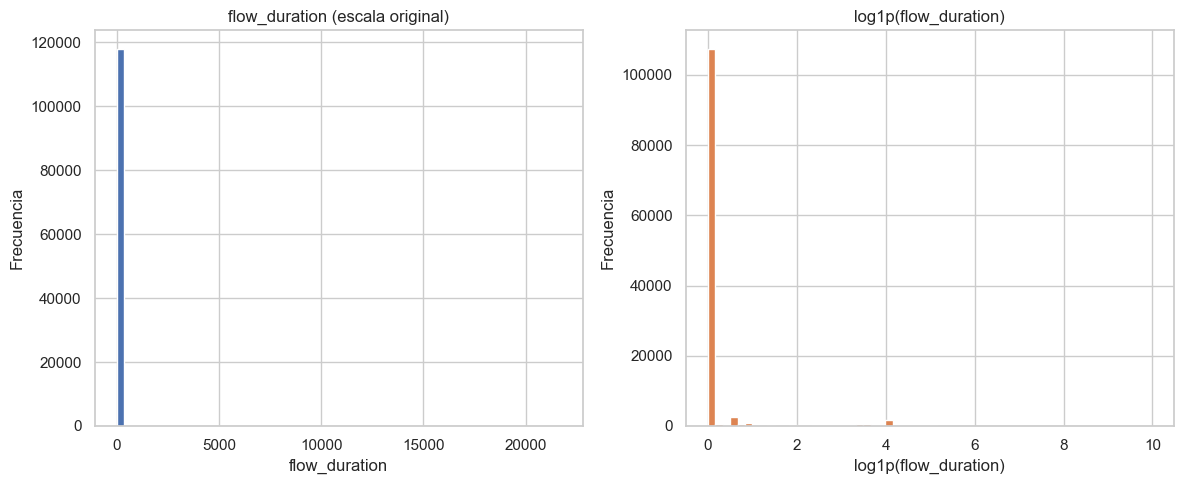

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["flow_duration"], bins=60, color="#4C72B0")
axes[0].set_title("flow_duration (escala original)")
axes[0].set_xlabel("flow_duration")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["flow_duration"]), bins=60, color="#DD8452")
axes[1].set_title("log1p(flow_duration)")
axes[1].set_xlabel("log1p(flow_duration)")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

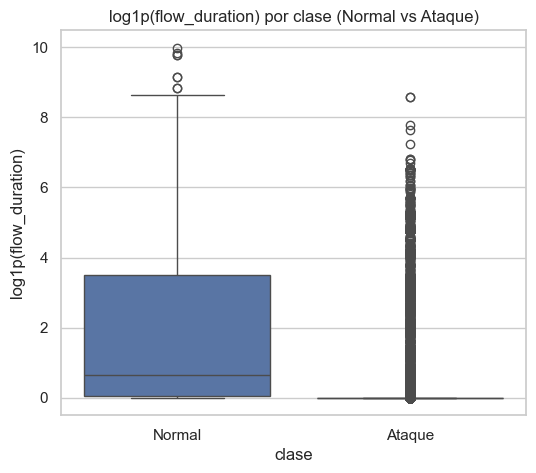

In [10]:
plot_df = pd.DataFrame({
    "flow_duration_log": np.log1p(df["flow_duration"]),
    "clase": y_bin.map({0: "Normal", 1: "Ataque"}),
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=plot_df, x="clase", y="flow_duration_log", hue="clase",
            palette={"Normal": "#4C72B0", "Ataque": "#C44E52"}, legend=False)
plt.title("log1p(flow_duration) por clase (Normal vs Ataque)")
plt.ylabel("log1p(flow_duration)")
plt.show()

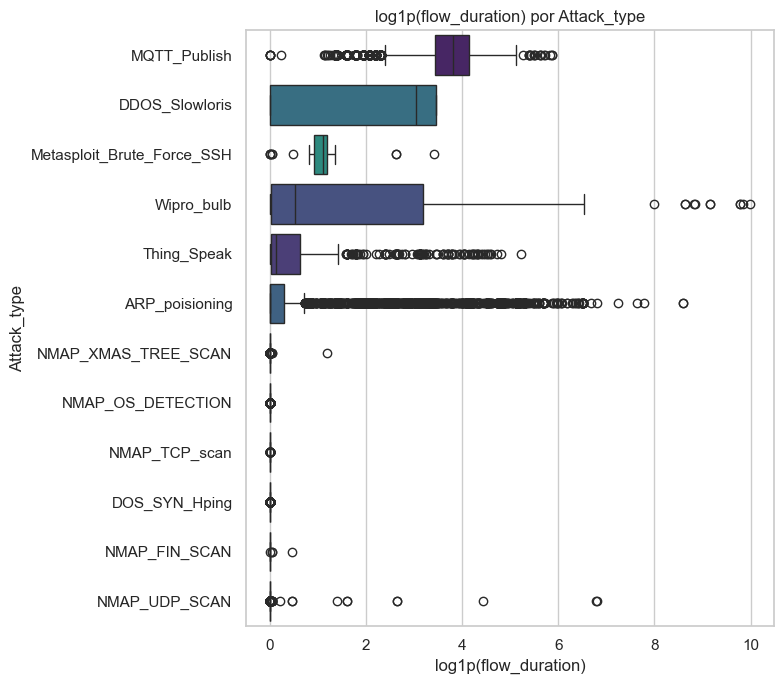

In [11]:
order = (
    df.assign(flow_duration_log=np.log1p(df["flow_duration"]))
    .groupby("Attack_type")["flow_duration_log"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(8, 7))
sns.boxplot(
    data=df.assign(flow_duration_log=np.log1p(df["flow_duration"])),
    y="Attack_type", x="flow_duration_log", order=order,
    hue="Attack_type", palette="viridis", legend=False,
)
plt.title("log1p(flow_duration) por Attack_type")
plt.xlabel("log1p(flow_duration)")
plt.tight_layout()
plt.show()

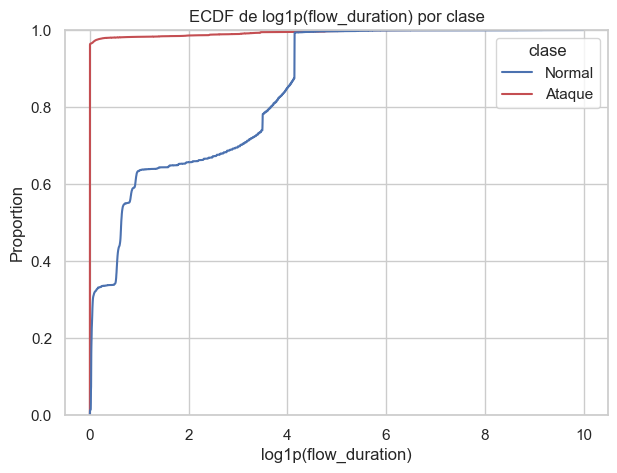

In [12]:
plt.figure(figsize=(7, 5))
sns.ecdfplot(data=plot_df, x="flow_duration_log", hue="clase",
             palette={"Normal": "#4C72B0", "Ataque": "#C44E52"})
plt.title("ECDF de log1p(flow_duration) por clase")
plt.xlabel("log1p(flow_duration)")
plt.show()

## 5. Valores extremos / outliers

La mediana global de `flow_duration` es casi 0, así que una regla clásica de outliers por IQR
(1.5·IQR sobre Q3) es poco informativa aquí: si Q1 y Q3 son casi 0, el límite superior también lo
es, y casi cualquier valor no-nulo queda marcado como "outlier". Por eso se complementa con un
análisis por cuantiles.

In [13]:
q1, q3 = df["flow_duration"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers_iqr = (df["flow_duration"] > upper_bound).sum()

print(f"Q1={q1:.6g}, Q3={q3:.6g}, IQR={iqr:.6g}, limite superior (1.5*IQR)={upper_bound:.6g}")
print(f"Filas por encima del limite: {n_outliers_iqr} ({n_outliers_iqr / len(df):.2%} del total)")


Q1=1e-06, Q3=5e-06, IQR=4e-06, limite superior (1.5*IQR)=1.1e-05
Filas por encima del limite: 18783 (15.93% del total)


In [14]:
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]

q_global = df["flow_duration"].quantile(quantiles)
q_por_clase = df.groupby(y_bin)["flow_duration"].quantile(quantiles).unstack(level=0)
q_por_clase.columns = ["Normal", "Ataque"]
q_por_clase["Global"] = q_global.values
q_por_clase.round(4)

,Normal,Ataque,Global
0.500,0.8882,0.0000,0.0000
0.750,31.9645,0.0000,0.0000
0.900,61.9689,0.0000,0.0642
0.950,62.0505,0.0002,4.8494
0.990,62.1442,20.1236,62.0473
0.999,653.4027,173.4828,194.1938
1.000,21728.3356,5341.3923,21728.3356


In [15]:
p99 = df["flow_duration"].quantile(0.99)
extreme = df[df["flow_duration"] > p99]
print(f"Filas con flow_duration > p99 ({p99:.4f}): {len(extreme)}")
print()
print("Distribucion de Attack_type en la cola extrema (>p99):")
extreme["Attack_type"].value_counts()

Filas con flow_duration > p99 (62.0473): 1180

Distribucion de Attack_type en la cola extrema (>p99):


Attack_type
MQTT_Publish      600
ARP_poisioning    527
Wipro_bulb         31
Thing_Speak        19
NMAP_UDP_SCAN       3
Name: count, dtype: int64

## 6. ¿Las duraciones separan limpiamente las clases?

Se evalúa qué tan bien `flow_duration`, usada *sola*, separa Normal de Ataque: comparación de
cuantiles entre clases, una regla de umbral único (referencia, no un modelo) y el
ROC-AUC/PR-AUC de esta única variable.

In [16]:
p90_ataque = df.loc[y_bin == 1, "flow_duration"].quantile(0.90)
p10_normal = df.loc[y_bin == 0, "flow_duration"].quantile(0.10)
print(f"P90(Ataque) = {p90_ataque:.6g}   vs   P10(Normal) = {p10_normal:.6g}")
print("Si P90(Ataque) < P10(Normal): el 90% mas corto de los ataques cae por debajo del 90% mas")
print("largo de los normales -> separacion casi total en el grueso de la distribucion.")


P90(Ataque) = 6e-06   vs   P10(Normal) = 0.0266802
Si P90(Ataque) < P10(Normal): el 90% mas corto de los ataques cae por debajo del 90% mas
largo de los normales -> separacion casi total en el grueso de la distribucion.


In [17]:
thresholds = np.unique(df["flow_duration"].quantile(np.linspace(0.01, 0.99, 197)))
best_thr, best_f1m = None, -1.0
for thr in thresholds:
    pred = (df["flow_duration"] <= thr).astype(int)  # 1 = Ataque (duracion corta)
    f1m = f1_score(y_bin, pred, average="macro", zero_division=0)
    if f1m > best_f1m:
        best_f1m, best_thr = f1m, thr

print(f"Mejor umbral (regla ingenua 'Ataque si flow_duration <= thr'): thr={best_thr:.6g}")
print(f"F1-macro de esta regla de un solo umbral: {best_f1m:.4f}")
print("Se presenta solo como referencia de cuanto separa flow_duration por si sola; no es un modelo.")


Mejor umbral (regla ingenua 'Ataque si flow_duration <= thr'): thr=0.00277259
F1-macro de esta regla de un solo umbral: 0.9150
Se presenta solo como referencia de cuanto separa flow_duration por si sola; no es un modelo.


ROC-AUC usando solo flow_duration (duracion corta = Ataque): 0.9739
PR-AUC usando solo flow_duration: 0.9959


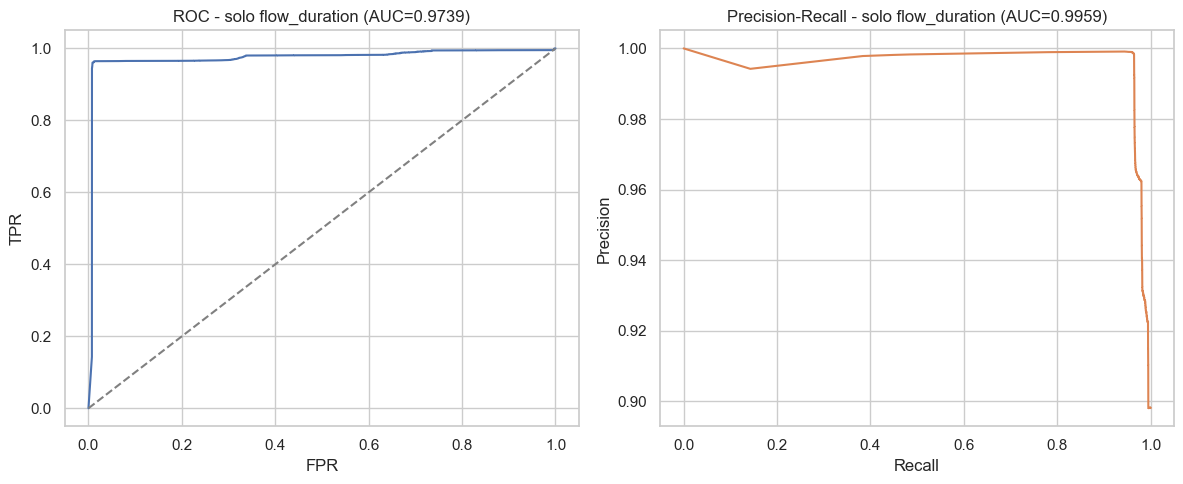

In [18]:
roc_auc_fd = roc_auc_score(y_bin, -df["flow_duration"])
pr_auc_fd = average_precision_score(y_bin, -df["flow_duration"])
print(f"ROC-AUC usando solo flow_duration (duracion corta = Ataque): {roc_auc_fd:.4f}")
print(f"PR-AUC usando solo flow_duration: {pr_auc_fd:.4f}")

fpr, tpr, _ = roc_curve(y_bin, -df["flow_duration"])
prec, rec, _ = precision_recall_curve(y_bin, -df["flow_duration"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color="#4C72B0")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title(f"ROC - solo flow_duration (AUC={roc_auc_fd:.4f})")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")

axes[1].plot(rec, prec, color="#DD8452")
axes[1].set_title(f"Precision-Recall - solo flow_duration (AUC={pr_auc_fd:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
plt.tight_layout()
plt.show()

## 7. Variable objetivo, variables leaky y split (mismo protocolo que 07)

Mismo `TARGET`, mismas variables leaky y mismo split 80/20 estratificado sobre `y_bin` que
`07_baseline_decision_tree.ipynb`, para que `X_test`/`y_test` sean exactamente comparables.

In [19]:
TARGET = "Attack_type"  # se mantiene en df por trazabilidad, no entra a X ni es el target
LEAKY_NUM = ["id.orig_p", "id.resp_p"]
LEAKY_CAT = ["proto", "service"]
BASE_NUM = [c for c in df.columns if c not in [TARGET, *LEAKY_NUM, *LEAKY_CAT]]

print(f"Features base (no leaky): {len(BASE_NUM)}")
X = df.drop(columns=[TARGET])

Features base (no leaky): 32


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bin
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print()
print("Proporcion de clases en train:")
print(y_train.value_counts(normalize=True).round(4))

Train: (94337, 36) Test: (23585, 36)

Proporcion de clases en train:
y_bin
1    0.8981
0    0.1019
Name: proportion, dtype: float64


## 8. Pipeline: con vs. sin `flow_duration`

Se generaliza `build_preprocessor(include_leaky)` de `07_baseline_decision_tree.ipynb` a una
versión que recibe una lista de columnas a excluir (`exclude_cols`), porque aquí se necesita
quitar una columna numérica específica (`flow_duration`), no un bloque leaky completo. **Ambas**
variantes de esta comparación son "sin leaky" (alcance recomendado en 07); la única diferencia
entre ellas es la presencia o ausencia de `flow_duration`. Mismos hiperparámetros del árbol
(`class_weight="balanced"`, sin restricción de profundidad, `random_state=42`) que el baseline
inicial de 07.

In [21]:
def build_preprocessor(exclude_cols=None) -> ColumnTransformer:
    exclude_cols = exclude_cols or []
    num_cols = [c for c in BASE_NUM if c not in exclude_cols]
    return ColumnTransformer([("num", "passthrough", num_cols)])


def build_pipeline(exclude_cols=None, **tree_kwargs) -> Pipeline:
    params = {"class_weight": "balanced", "random_state": RANDOM_STATE}
    params.update(tree_kwargs)
    return Pipeline([
        ("prep", build_preprocessor(exclude_cols)),
        ("clf", DecisionTreeClassifier(**params)),
    ])


VARIANTS = {"con_flow_duration": [], "sin_flow_duration": ["flow_duration"]}
pipelines = {name: build_pipeline(cols) for name, cols in VARIANTS.items()}

## 9. Entrenamiento de ambas variantes + tiempos de entrenamiento y predicción

In [22]:
fit_times = {}
predict_times = {}
for name, pipe in pipelines.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - t0

    t0 = time.perf_counter()
    pipe.predict(X_test)
    predict_times[name] = time.perf_counter() - t0

    print(f"{name}: fit_time = {fit_times[name]:.3f} s | predict_time = {predict_times[name]:.4f} s")

con_flow_duration: fit_time = 0.418 s | predict_time = 0.0146 s


sin_flow_duration: fit_time = 0.307 s | predict_time = 0.0135 s


## 10. Validación cruzada estratificada (`StratifiedKFold`)

5 folds sobre train (el test permanece reservado), mismo protocolo que 07.

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "f1_macro", "average_precision"]

cv_results = {}
for name, cols in VARIANTS.items():
    pipe = build_pipeline(cols)  # instancia fresca, no reusar el arbol ya ajustado
    cv_results[name] = cross_validate(
        pipe, X_train, y_train, cv=skf, scoring=scoring,
        return_train_score=True, n_jobs=-1,
    )

cv_summary_rows = []
for name, res in cv_results.items():
    row = {"variante": name}
    for metric in scoring:
        row[f"cv_val_{metric}_mean"] = res[f"test_{metric}"].mean()
        row[f"cv_val_{metric}_std"] = res[f"test_{metric}"].std()
        row[f"cv_train_{metric}_mean"] = res[f"train_{metric}"].mean()
    row["cv_fit_time_mean_s"] = res["fit_time"].mean()
    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows).set_index("variante")
cv_summary

,cv_val_accuracy_mean,cv_val_accuracy_std,cv_train_accuracy_mean,cv_val_precision_mean,cv_val_precision_std,cv_train_precision_mean,cv_val_recall_mean,cv_val_recall_std,cv_train_recall_mean,cv_val_f1_mean,cv_val_f1_std,cv_train_f1_mean,cv_val_f1_macro_mean,cv_val_f1_macro_std,cv_train_f1_macro_mean,cv_val_average_precision_mean,cv_val_average_precision_std,cv_train_average_precision_mean,cv_fit_time_mean_s
variante,,,,,,,,,,,,,,,,,,,
con_flow_duration,0.998219,0.000499,0.999889,0.998820,0.000338,0.999976,0.999197,0.000333,0.9999,0.999009,0.000278,0.999938,0.995127,0.001364,0.999696,0.998748,0.000348,1.0,0.710028
sin_flow_duration,0.998336,0.000261,0.999889,0.998879,0.000261,0.999976,0.999268,0.000169,0.9999,0.999074,0.000145,0.999938,0.995446,0.000716,0.999696,0.998815,0.000245,1.0,0.942765


## 11. Evaluación en el test reservado

In [24]:
def evaluate_on_test(pipe, name, label="test"):
    t0 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    predict_time = time.perf_counter() - t0
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "pr_auc": average_precision_score(y_test, y_proba),
        "predict_time_s": predict_time,
    }
    print(f"\n=== {name} - classification_report ({label}) ===")
    print(classification_report(y_test, y_pred, target_names=["Normal(0)", "Ataque(1)"], zero_division=0))
    return metrics, y_pred


test_metrics = {}
test_preds = {}
for name, pipe in pipelines.items():
    metrics, y_pred = evaluate_on_test(pipe, name)
    test_metrics[name] = metrics
    test_preds[name] = y_pred


=== con_flow_duration - classification_report (test) ===
              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      2403
   Ataque(1)       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      0.99      1.00     23585
weighted avg       1.00      1.00      1.00     23585


=== sin_flow_duration - classification_report (test) ===
              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      2403
   Ataque(1)       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      0.99      1.00     23585
weighted avg       1.00      1.00      1.00     23585



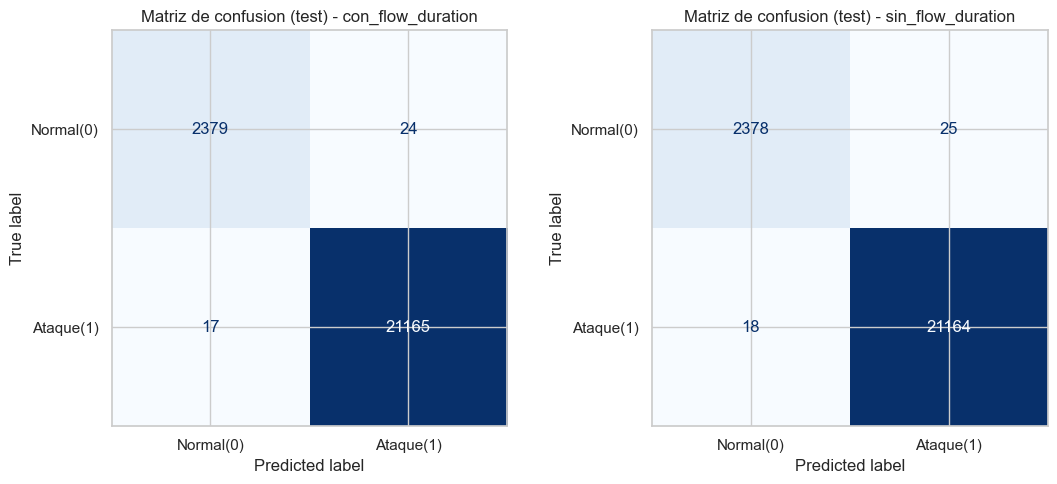

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, y_pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Ataque(1)"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusion (test) - {name}")
plt.tight_layout()
plt.show()

## 12. Tabla comparativa: con vs. sin `flow_duration`

Mismas columnas que la tabla comparativa de `07_baseline_decision_tree.ipynb`, más una fila
`delta` (`sin_flow_duration` − `con_flow_duration`) para que el efecto de remover la variable
sea explícito.

In [26]:
rows = []
for name in VARIANTS:
    clf = pipelines[name].named_steps["clf"]
    rows.append({
        "variante": name,
        "accuracy": test_metrics[name]["accuracy"],
        "precision": test_metrics[name]["precision"],
        "recall": test_metrics[name]["recall"],
        "f1": test_metrics[name]["f1"],
        "f1_macro": test_metrics[name]["f1_macro"],
        "pr_auc": test_metrics[name]["pr_auc"],
        "cv_f1_macro_mean": cv_summary.loc[name, "cv_val_f1_macro_mean"],
        "cv_f1_macro_std": cv_summary.loc[name, "cv_val_f1_macro_std"],
        "fit_time_s": fit_times[name],
        "predict_time_s": predict_times[name],
        "tree_depth": clf.get_depth(),
        "tree_leaves": clf.get_n_leaves(),
    })

comparison = pd.DataFrame(rows).set_index("variante")
delta = comparison.loc["sin_flow_duration"] - comparison.loc["con_flow_duration"]
delta.name = "delta (sin - con)"
comparison = pd.concat([comparison, delta.to_frame().T])
comparison.round(4)

,accuracy,precision,recall,f1,f1_macro,pr_auc,cv_f1_macro_mean,cv_f1_macro_std,fit_time_s,predict_time_s,tree_depth,tree_leaves
con_flow_duration,0.9983,0.9989,0.9992,0.999,0.9952,0.9988,0.9951,0.0014,0.4181,0.0146,23.0,207.0
sin_flow_duration,0.9982,0.9988,0.9992,0.999,0.9950,0.9988,0.9954,0.0007,0.3068,0.0135,19.0,228.0
delta (sin - con),-0.0001,-0.0000,-0.0000,-0.000,-0.0002,-0.0000,0.0003,-0.0006,-0.1113,-0.0011,-4.0,21.0


In [27]:
cm_con = confusion_matrix(y_test, test_preds["con_flow_duration"], labels=[0, 1])
cm_sin = confusion_matrix(y_test, test_preds["sin_flow_duration"], labels=[0, 1])
print("Matriz de confusion - con_flow_duration (TN, FP / FN, TP):")
print(cm_con)
print()
print("Matriz de confusion - sin_flow_duration (TN, FP / FN, TP):")
print(cm_sin)

Matriz de confusion - con_flow_duration (TN, FP / FN, TP):
[[ 2379    24]
 [   17 21165]]

Matriz de confusion - sin_flow_duration (TN, FP / FN, TP):
[[ 2378    25]
 [   18 21164]]


## 13. Importancia de variables: antes vs. después de quitar `flow_duration`

Comparación de las importancias Gini de ambas variantes y de qué variables *ganan* importancia
cuando `flow_duration` deja de estar disponible.


Top 10 - con_flow_duration
flow_duration            0.9094
flow_pkts_payload.min    0.0187
bwd_init_window_size     0.0162
bwd_pkts_tot             0.0115
fwd_subflow_bytes        0.0103
fwd_header_size_max      0.0100
flow_CWR_flag_count      0.0058
flow_pkts_payload.std    0.0038
flow_pkts_payload.max    0.0030
bwd_pkts_payload.min     0.0018
dtype: float64

Top 10 - sin_flow_duration
bwd_pkts_payload.avg     0.8735
flow_pkts_per_sec        0.0312
fwd_data_pkts_tot        0.0157
flow_pkts_payload.avg    0.0149
fwd_subflow_bytes        0.0118
flow_pkts_payload.min    0.0090
fwd_last_window_size     0.0088
fwd_header_size_max      0.0080
fwd_pkts_tot             0.0055
bwd_init_window_size     0.0041
dtype: float64


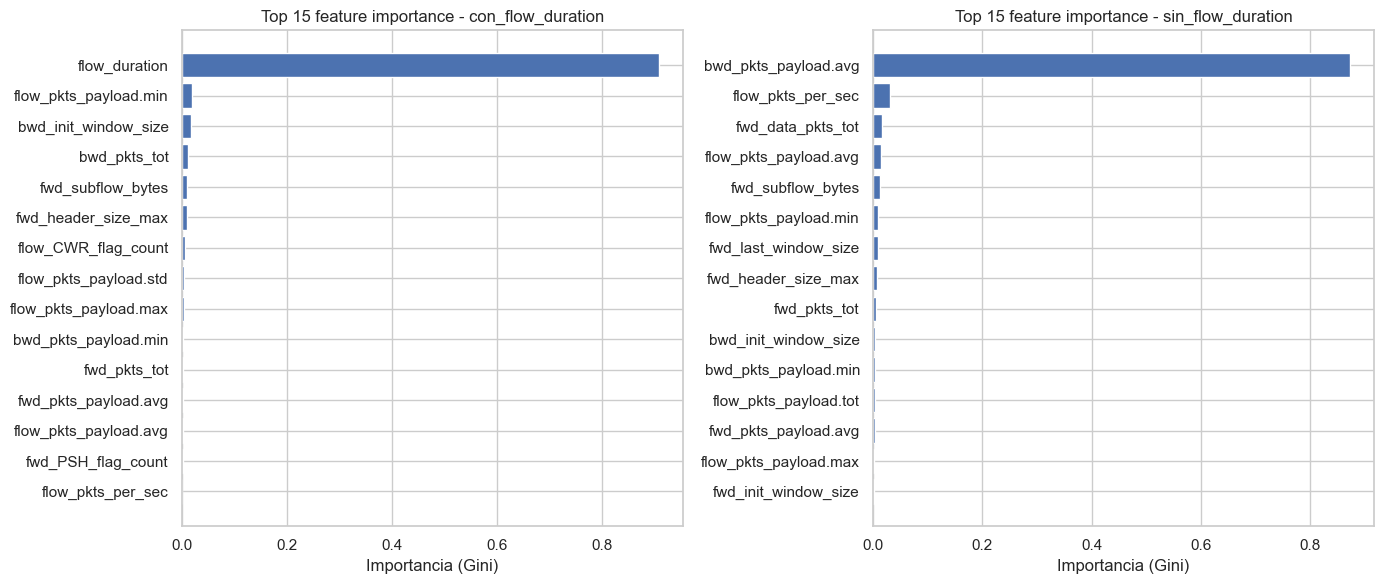

In [28]:
def get_feature_importances(pipe):
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    names = [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]
    return pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False)


importances = {name: get_feature_importances(pipe) for name, pipe in pipelines.items()}

for name, imp in importances.items():
    print(f"\nTop 10 - {name}")
    print(imp.head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, imp) in zip(axes, importances.items()):
    top = imp.head(15)[::-1]
    ax.barh(top.index, top.values, color="#4C72B0")
    ax.set_title(f"Top 15 feature importance - {name}")
    ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

In [29]:
imp_delta = pd.concat(
    [importances["con_flow_duration"].rename("con_flow_duration"),
     importances["sin_flow_duration"].rename("sin_flow_duration")],
    axis=1,
).fillna(0.0)
imp_delta["delta"] = imp_delta["sin_flow_duration"] - imp_delta["con_flow_duration"]
imp_delta.sort_values("delta", ascending=False).head(15).round(4)

,con_flow_duration,sin_flow_duration,delta
bwd_pkts_payload.avg,0.0006,0.8735,0.8729
flow_pkts_per_sec,0.0008,0.0312,0.0304
fwd_data_pkts_tot,0.0000,0.0157,0.0157
flow_pkts_payload.avg,0.0012,0.0149,0.0137
fwd_last_window_size,0.0004,0.0088,0.0084
fwd_pkts_tot,0.0015,0.0055,0.0041
flow_pkts_payload.tot,0.0007,0.0030,0.0023
fwd_pkts_payload.avg,0.0012,0.0030,0.0017
bwd_pkts_payload.min,0.0018,0.0035,0.0017
fwd_subflow_bytes,0.0103,0.0118,0.0015


## 14. Diagnóstico de sobreajuste (train vs. CV vs. test)

Mismo patrón que 07: si quitar `flow_duration` cambiara la brecha train–CV de forma relevante,
sería una señal de que el árbol empieza a memorizar en vez de generalizar sin esa variable.

In [30]:
overfit_rows = []
for name in VARIANTS:
    clf = pipelines[name].named_steps["clf"]
    train_pred = pipelines[name].predict(X_train)
    overfit_rows.append({
        "variante": name,
        "train_f1_macro": f1_score(y_train, train_pred, average="macro", zero_division=0),
        "cv_val_f1_macro": cv_summary.loc[name, "cv_val_f1_macro_mean"],
        "test_f1_macro": test_metrics[name]["f1_macro"],
        "tree_depth": clf.get_depth(),
        "tree_leaves": clf.get_n_leaves(),
    })

overfit_df = pd.DataFrame(overfit_rows).set_index("variante")
overfit_df["gap_train_vs_cv"] = overfit_df["train_f1_macro"] - overfit_df["cv_val_f1_macro"]
overfit_df.round(4)

,train_f1_macro,cv_val_f1_macro,test_f1_macro,tree_depth,tree_leaves,gap_train_vs_cv
variante,,,,,,
con_flow_duration,0.9997,0.9951,0.9952,23,207,0.0046
sin_flow_duration,0.9997,0.9954,0.9950,19,228,0.0042


## 15. Distribución de la variable que asume el liderazgo tras quitar `flow_duration`

Se repite un análisis ligero (estadísticos por clase, boxplot, correlación con `flow_duration`)
para la variable que más importancia gana en la variante `sin_flow_duration`, con el fin de
verificar si es una señal genuinamente distinta o un simple proxy correlacionado.

In [31]:
top_new_feature = imp_delta.sort_values("delta", ascending=False).index[0]
print(f"Variable que mas importancia gana al quitar flow_duration: {top_new_feature}")

corr_con_flow_duration = df[top_new_feature].corr(df["flow_duration"])
print(f"Correlacion de Pearson con flow_duration: {corr_con_flow_duration:.4f}")

desc_top_new_por_clase = df.groupby(y_bin)[top_new_feature].describe()
desc_top_new_por_clase.index = desc_top_new_por_clase.index.map({0: "Normal", 1: "Ataque"})
desc_top_new_por_clase

Variable que mas importancia gana al quitar flow_duration: bwd_pkts_payload.avg
Correlacion de Pearson con flow_duration: 0.0274


,count,mean,std,min,25%,50%,75%,max
y_bin,,,,,,,,
Normal,12015.0,93.724007,147.676271,0.0,6.0,52.0,107.6,1345.966673
Ataque,105907.0,10.831961,69.666108,0.0,0.0,0.0,0.0,1457.052632


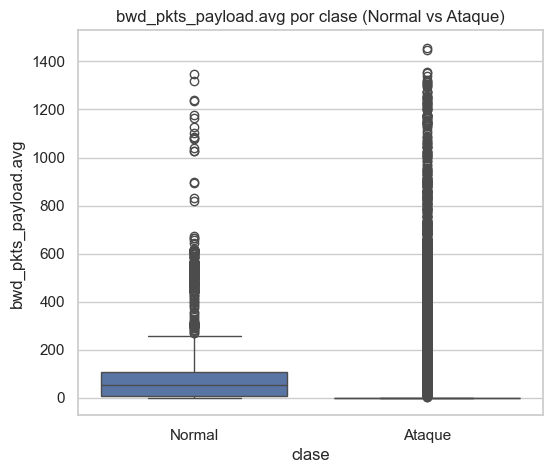

In [32]:
plot_df2 = pd.DataFrame({
    top_new_feature: df[top_new_feature],
    "clase": y_bin.map({0: "Normal", 1: "Ataque"}),
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=plot_df2, x="clase", y=top_new_feature, hue="clase",
            palette={"Normal": "#4C72B0", "Ataque": "#C44E52"}, legend=False)
plt.title(f"{top_new_feature} por clase (Normal vs Ataque)")
plt.show()

## 16. Respuestas

### ¿Por qué `flow_duration` tiene tanta importancia?

Porque separa casi perfectamente el grueso de las dos clases en un solo corte. El 89.81% de las
filas son "Ataque" (105.907), y de esas, ~92.3% (DOS_SYN_Hping: 90.089 filas + los 5 tipos de
escaneo NMAP: 7.624 filas) tienen `flow_duration` prácticamente cero (mediana global 0.000004 s).
El tráfico "Normal" (MQTT_Publish, Thing_Speak, Wipro_bulb — 12.015 filas), en cambio, corresponde
a sesiones sostenidas: mediana 0.888 s, P75 ≈32 s. La proporción de duración cero es 14.28% en
Ataque contra solo 0.73% en Normal. Un árbol de Gini sin restricción de profundidad encuentra ese
único punto de corte (~2.77 ms) casi de inmediato y le asigna casi todo el presupuesto de
importancia porque resuelve la mayoría del problema en un solo split cerca de la raíz.

### ¿La diferencia entre Normal y Ataque puede explicarse principalmente por esta variable?

En gran parte, pero no del todo. Usada como única variable, `flow_duration` obtiene ROC-AUC
0.9739 y PR-AUC 0.9959, y la mejor regla de un solo umbral (`flow_duration <= 0.00277 s`) logra
F1-macro 0.9150 — fuerte, pero 8 puntos por debajo del árbol completo (F1-macro 0.9952). La tabla
de cuantiles confirma que el percentil 90 de Ataque (6e-6 s) está muy por debajo del percentil 10
de Normal (0.0267 s): separación casi total en el grueso de la distribución. Sin embargo, la cola
extrema (>P99, `flow_duration` > 62.05 s, 1.180 filas) mezcla ambas clases: 600 MQTT_Publish y 19
Thing_Speak (Normal) junto con 527 ARP_poisioning y 3 NMAP_UDP_SCAN (Ataque) — esa cola es la que
un modelo debe resolver con otras variables.

### ¿Qué ocurre con el desempeño al eliminarla?

Prácticamente nada cambia. En test: accuracy 0.9983→0.9982, F1-macro 0.9952→0.9950 (delta
−0.0002), PR-AUC se mantiene en 0.9988. La matriz de confusión pasa de TN=2379/FP=24/FN=17/TP=21165
a TN=2378/FP=25/FN=18/TP=21164 — un error adicional de cada tipo sobre 23.585 filas de test. En CV
(5-fold), el F1-macro incluso sube ligeramente (0.9951±0.0014 → 0.9954±0.0007, con menor
variabilidad). El árbol resultante es más corto (profundidad 23→19) pero con más hojas (207→228).

### ¿El modelo sigue funcionando adecuadamente?

Sí. El diagnóstico de sobreajuste no muestra deterioro: F1-macro train (CV) se mantiene en 0.9997,
la brecha train–CV incluso se reduce levemente (0.0046→0.0042) al quitar `flow_duration`. El árbol
sin esta variable generaliza igual de bien que el original — no depende de un atajo que se rompa
al removerla.

### ¿Existe riesgo de que el resultado esté demasiado condicionado por esta característica?

Hay que separar dos niveles. A nivel de **desempeño**, el riesgo es bajo: quitar `flow_duration`
apenas mueve las métricas (ver arriba), así que el modelo no depende de un único atajo frágil. Pero
a nivel de **interpretación**, el riesgo es real: al remover `flow_duration`, una sola variable
nueva —`bwd_pkts_payload.avg`— salta de 0.06% a 87.35% de importancia (correlación de Pearson con
`flow_duration` de solo 0.0274, es decir, es una señal genuinamente distinta, no un proxy). Sus
estadísticos por clase muestran el mismo patrón subyacente: mediana 52.0 en Normal vs. mediana 0.0
en Ataque (media 93.72 vs. 10.83) — tráfico de ataque que no recibe payload de respuesta (flujos de
una sola vía: floods/escaneos) frente a sesiones IoT legítimas con payload bidireccional real. El
árbol siempre concentra ~87–91% de su importancia en una sola variable porque el dataset contiene
varias señales casi-univariadas que separan casi perfectamente esta mezcla particular de ataques
(mayormente floods y escaneos automatizados de un solo paquete/dirección). El riesgo a vigilar no
es que el modelo "solo sepa de `flow_duration`", sino que las métricas ~99.5% pueden no generalizar
a ataques que no compartan esta firma de flujo corto / sin payload de retorno (p. ej. ataques más
sigilosos o de mayor duración).

### ¿Qué variables adquieren importancia después de eliminarla?

En orden de ganancia (`sin_flow_duration − con_flow_duration`): `bwd_pkts_payload.avg` (+0.8729,
→87.35%), `flow_pkts_per_sec` (+0.0304, →3.12%), `fwd_data_pkts_tot` (+0.0157), `flow_pkts_payload.avg`
(+0.0137), `fwd_last_window_size` (+0.0084), `fwd_pkts_tot` (+0.0041), `flow_pkts_payload.tot`
(+0.0023), `fwd_pkts_payload.avg` (+0.0017), `bwd_pkts_payload.min` (+0.0017) y `fwd_subflow_bytes`
(+0.0015, variable que ya estaba en el top 5 original). El patrón se repite: casi todas describen
volumen/dirección de payload y tasa de paquetes — variables consistentes con la misma hipótesis de
"flujo corto y unidireccional (ataque)" vs. "sesión sostenida y bidireccional (normal)".


## 17. Persistencia del modelo `sin_flow_duration` (opcional, trazabilidad)

Se guarda el pipeline `sin_flow_duration` para dejar registro del experimento, siguiendo la
convención de `07_baseline_decision_tree.ipynb`. No reemplaza al baseline oficial
(`models/decision_tree_baseline.pkl`).

In [33]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, "decision_tree_sin_flow_duration.pkl")
joblib.dump(pipelines["sin_flow_duration"], model_path)
print(f"Modelo guardado en {model_path}")

loaded = joblib.load(model_path)
reload_pred = loaded.predict(X_test)
assert accuracy_score(y_test, reload_pred) == test_metrics["sin_flow_duration"]["accuracy"]
print("Recarga verificada: metricas consistentes.")

Modelo guardado en ../models\decision_tree_sin_flow_duration.pkl
Recarga verificada: metricas consistentes.
